# Notebook V4 - Prédiction d'intensité (version soutenance)

Ce notebook V4 combine:
- la démarche robuste de `train_model_intensité_v3.ipynb` (EDA, split, CV, métriques),
- la logique métier de `app.py` (features physiologiques et cible plus cohérente).

## Objectifs
- Produire un pipeline **plus crédible physiologiquement**.
- Comparer **RandomForest**, **XGBoost** et **LogisticRegression** sur la même base.
- Générer des artefacts réutilisables dans l'app.


## Plan du notebook

1. Imports et configuration
2. Chargement des données (fallback local)
3. Contrôles qualité (schéma, NA, distributions)
4. Préparation V4: nettoyage + feature engineering + cible physiologique
5. Split train/test + entraînement des 3 modèles
6. Évaluation (test + validation croisée)
7. Comparatif final et lecture métier
8. Sauvegarde des artefacts (optionnel)
9. Fonction d'inférence unitaire (alignée app)


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise RuntimeError('xgboost est requis: pip install xgboost') from exc


In [2]:
# Chemins de données: priorité au dataset le plus réaliste
BASE_DIR = Path('/home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML')
DATA_CANDIDATES = [
    BASE_DIR / 'gym_members_exercise_tracking_v2_realiste.csv',
    BASE_DIR / 'gym_members_exercise_tracking_v2.csv',
    BASE_DIR / 'gym_members_exercise_tracking.csv',
]


def resolve_data_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f'Aucun fichier trouve parmi: {candidates}')


csv_path = resolve_data_path(DATA_CANDIDATES)
print('CSV utilise :', csv_path)

df_raw = pd.read_csv(csv_path)
print('Shape brut :', df_raw.shape)
df_raw.head()


CSV utilise : /home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML/gym_members_exercise_tracking_v2.csv
Shape brut : (973, 15)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,54,Male,61.0,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,20.86
1,49,Female,63.1,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,26.96
2,30,Female,65.8,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,23.88
3,23,Male,73.5,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,25.43
4,37,Male,73.4,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,22.91


## Contrôles qualité rapides

On vérifie d'abord la structure et la qualité minimale des données.


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

In [4]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
display(missing_table[missing_table['missing_count'] > 0])

if (missing > 0).sum() == 0:
    print('Aucune valeur manquante detectee.')


,missing_count,missing_pct


Aucune valeur manquante detectee.


In [5]:
num_cols_raw = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_raw = df_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numeriques :', num_cols_raw)
print('Categorielles :', cat_cols_raw)


Numeriques : ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']
Categorielles : ['Gender', 'Workout_Type']


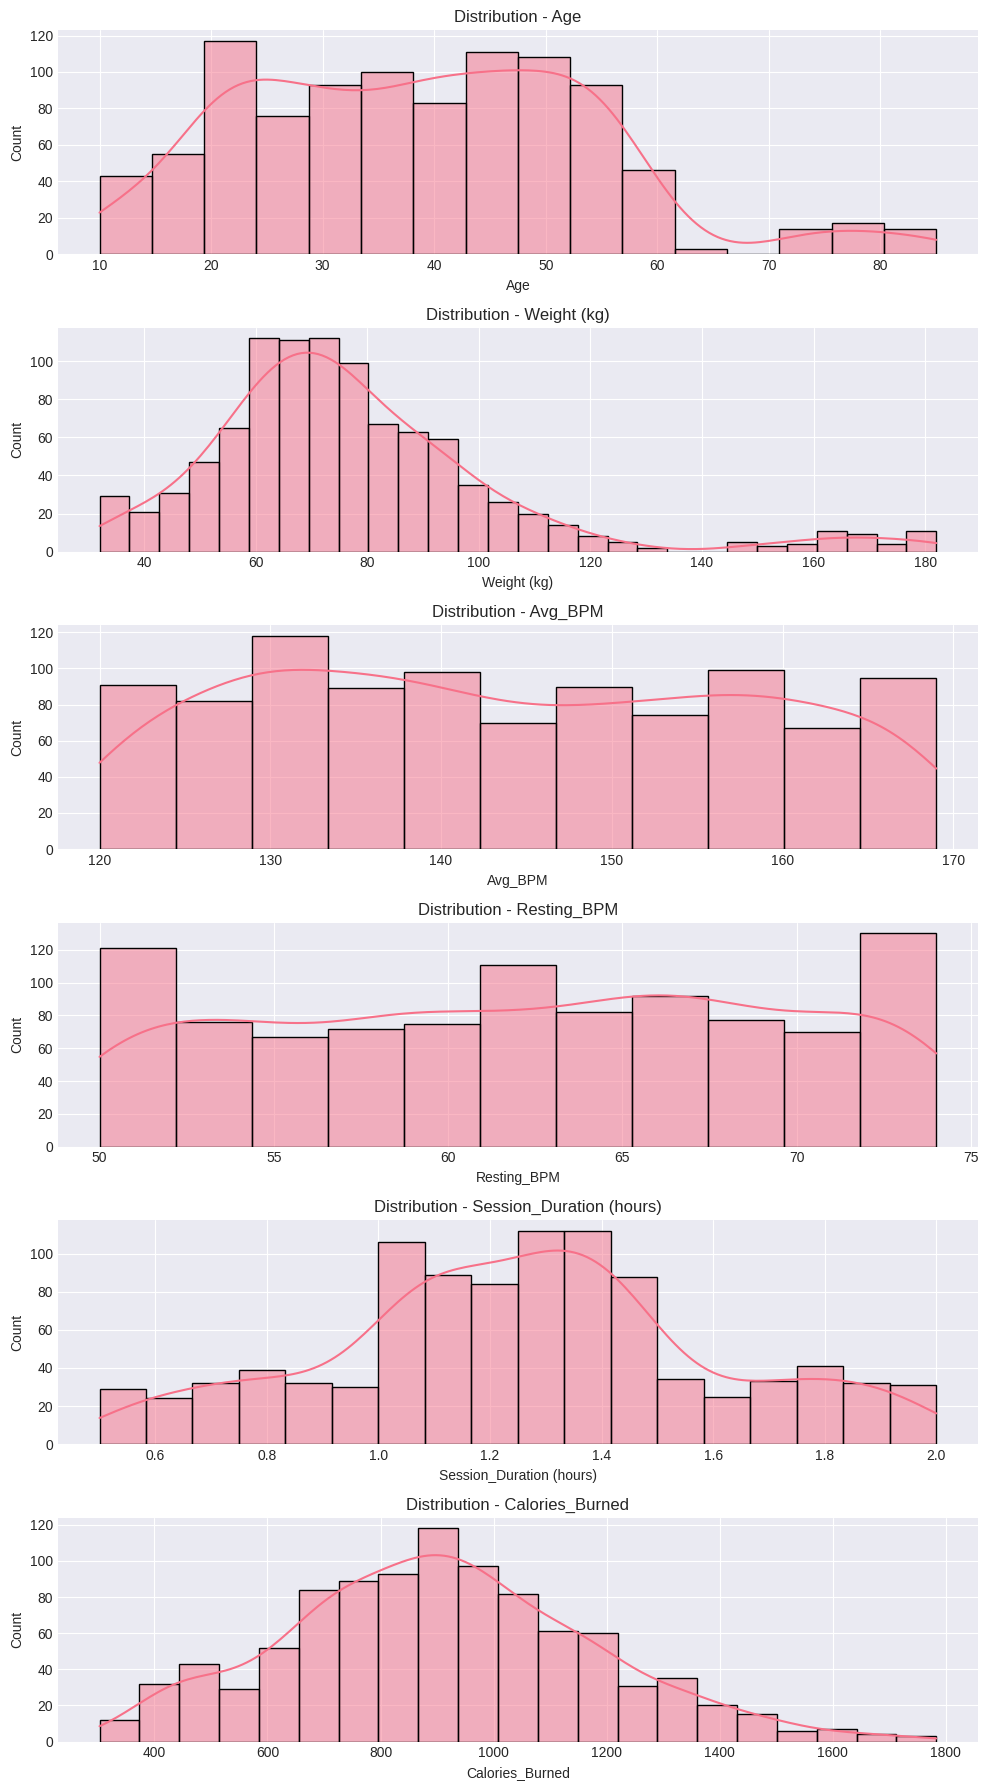

In [6]:
# Distributions de base (subset)
cols_to_plot = [c for c in ['Age', 'Weight (kg)', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned'] if c in df_raw.columns]
fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 3 * len(cols_to_plot)))
if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    sns.histplot(df_raw[col], kde=True, ax=ax)
    ax.set_title(f'Distribution - {col}')

plt.tight_layout()
plt.show()


## Préparation V4 (alignée avec `app.py`)

Différences clés vs V3:
- Nettoyage de bornes physiologiques pour réduire le bruit.
- Features dérivées cardio (`hr_ratio_reserve`, `bpm_reserve`, `effort_load`).
- Cible `intensite` dérivée d'un score physiologique (et pas uniquement de `Calories_Burned`).


In [7]:
def to_intensity(score: pd.Series) -> pd.Series:
    q1, q2 = score.quantile([0.33, 0.66])

    def _map(x: float) -> str:
        if x <= q1:
            return 'faible'
        if x <= q2:
            return 'moyen'
        return 'eleve'

    return score.apply(_map)


def prepare_dataset_v4(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    # 1) Nettoyage physiologique simple
    data = data[
        (data['Age'].between(16, 80))
        & (data['Weight (kg)'].between(40, 160))
        & (data['Session_Duration (hours)'].between(0.3, 3.0))
        & (data['Resting_BPM'].between(35, 110))
        & (data['Avg_BPM'].between(90, 210))
    ].copy()

    # 2) Features dérivées
    hr_max_theorique = 220 - data['Age']
    denom = (hr_max_theorique - data['Resting_BPM']).replace(0, np.nan)
    data['hr_ratio_reserve'] = (data['Avg_BPM'] - data['Resting_BPM']) / denom
    data['bpm_reserve'] = data['Avg_BPM'] - data['Resting_BPM']
    data['effort_load'] = data['hr_ratio_reserve'] * data['Session_Duration (hours)'] * (data['Weight (kg)'] / 70.0)

    # 3) Cible physiologique
    intensity_score = (
        0.70 * data['hr_ratio_reserve']
        + 0.20 * (data['Session_Duration (hours)'] / 2.0)
        + 0.10 * ((data['Avg_BPM'] - 100.0) / 100.0)
    )
    data['intensite'] = to_intensity(intensity_score)

    features = [
        'Age', 'Weight (kg)', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)',
        'Workout_Type', 'hr_ratio_reserve', 'bpm_reserve', 'effort_load'
    ]

    model_df = data[features + ['intensite']].replace([np.inf, -np.inf], np.nan).dropna()
    return model_df


model_df = prepare_dataset_v4(df_raw)
print('Shape apres preparation :', model_df.shape)
print(model_df['intensite'].value_counts(normalize=True).round(3))
model_df.head()


Shape apres preparation : (881, 10)
intensite
eleve     0.341
faible    0.330
moyen     0.329
Name: proportion, dtype: float64


,Age,Weight (kg),Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,hr_ratio_reserve,bpm_reserve,effort_load,intensite
0,54,61.0,157,60,1.69,Yoga,0.915094,97,1.347673,eleve
1,49,63.1,151,66,1.30,HIIT,0.809524,85,0.948646,eleve
2,30,65.8,122,54,1.11,Cardio,0.500000,68,0.521700,faible
3,23,73.5,164,56,0.59,Strength,0.765957,108,0.474511,moyen
4,37,73.4,158,68,0.64,Strength,0.782609,90,0.525198,moyen


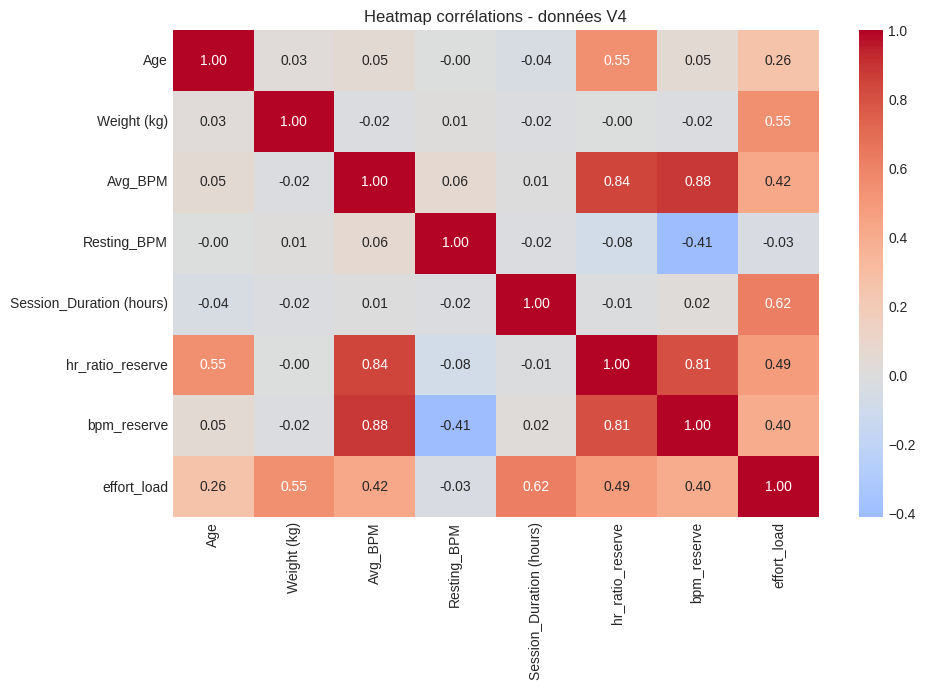

In [8]:
# Corrélation des variables numériques préparées
corr = model_df.select_dtypes(include=['number']).corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap corrélations - données V4')
plt.tight_layout()
plt.show()


## Split train/test + entraînement

Important: on conserve un split stratifié pour pouvoir comparer les modèles proprement.


In [9]:
X_raw = model_df.drop(columns=['intensite']).copy()
y = model_df['intensite'].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train_raw.shape, '| X_test:', X_test_raw.shape)
print('Distribution train:')
print(y_train.value_counts(normalize=True).round(3))
print('Distribution test:')
print(y_test.value_counts(normalize=True).round(3))


X_train: (704, 9) | X_test: (177, 9)
Distribution train:
intensite
eleve     0.341
faible    0.330
moyen     0.330
Name: proportion, dtype: float64
Distribution test:
intensite
eleve     0.339
faible    0.333
moyen     0.328
Name: proportion, dtype: float64


In [10]:
# Encodage explicite pour RF et XGB (comme dans app.py)
X_train_ohe = pd.get_dummies(X_train_raw, columns=['Workout_Type'], drop_first=True)
X_test_ohe = pd.get_dummies(X_test_raw, columns=['Workout_Type'], drop_first=True)
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)

# RandomForest
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)
rf.fit(X_train_ohe, y_train)

# XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    num_class=len(le.classes_),
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1,
)
xgb.fit(X_train_ohe, y_train_enc)

# LogisticRegression en pipeline (interprétable)
num_cols = [
    'Age', 'Weight (kg)', 'Avg_BPM', 'Resting_BPM',
    'Session_Duration (hours)', 'hr_ratio_reserve', 'bpm_reserve', 'effort_load'
]
cat_cols = ['Workout_Type']

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ]
)

lr = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(solver='lbfgs', max_iter=3000, class_weight='balanced', random_state=42)),
])
lr.fit(X_train_raw, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Évaluation sur jeu de test

On compare Accuracy et F1 macro, puis on inspecte les rapports de classification.


In [11]:
def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    print(f'[{name}] Accuracy: {acc:.4f} | F1 macro: {f1m:.4f}')
    print(classification_report(y_true, y_pred, digits=4))
    return {'Modele': name, 'Accuracy': acc, 'F1_macro': f1m}

rf_pred = rf.predict(X_test_ohe)
xgb_pred = le.inverse_transform(xgb.predict(X_test_ohe))
lr_pred = lr.predict(X_test_raw)

res_test = []
res_test.append(evaluate_classifier('RandomForest', y_test, rf_pred))
res_test.append(evaluate_classifier('XGBoost', y_test, xgb_pred))
res_test.append(evaluate_classifier('LogisticRegression', y_test, lr_pred))

results_test_df = pd.DataFrame(res_test).sort_values('F1_macro', ascending=False)
display(results_test_df.style.format({'Accuracy': '{:.4f}', 'F1_macro': '{:.4f}'}))


[RandomForest] Accuracy: 0.9266 | F1 macro: 0.9266
              precision    recall  f1-score   support

       eleve     0.9474    0.9000    0.9231        60
      faible     0.9661    0.9661    0.9661        59
       moyen     0.8689    0.9138    0.8908        58

    accuracy                         0.9266       177
   macro avg     0.9274    0.9266    0.9266       177
weighted avg     0.9279    0.9266    0.9268       177

[XGBoost] Accuracy: 0.9379 | F1 macro: 0.9378
              precision    recall  f1-score   support

       eleve     0.9643    0.9000    0.9310        60
      faible     0.9667    0.9831    0.9748        59
       moyen     0.8852    0.9310    0.9076        58

    accuracy                         0.9379       177
   macro avg     0.9387    0.9380    0.9378       177
weighted avg     0.9392    0.9379    0.9379       177

[LogisticRegression] Accuracy: 0.9661 | F1 macro: 0.9661
              precision    recall  f1-score   support

       eleve     1.0000    0.

,Modele,Accuracy,F1_macro
2,LogisticRegression,0.9661,0.9661
1,XGBoost,0.9379,0.9378
0,RandomForest,0.9266,0.9266


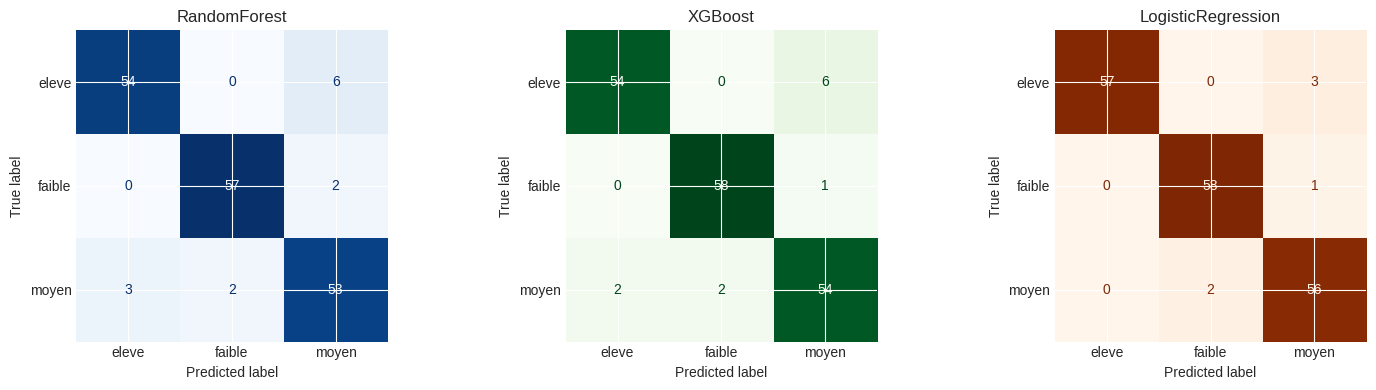

In [12]:
labels = sorted(y.unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, pred, cmap in [
    (axes[0], 'RandomForest', rf_pred, 'Blues'),
    (axes[1], 'XGBoost', xgb_pred, 'Greens'),
    (axes[2], 'LogisticRegression', lr_pred, 'Oranges'),
]:
    cm = confusion_matrix(y_test, pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## Validation croisée (stabilité)

On mesure la robustesse avec une CV 5-fold sur F1 macro.


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV RF (encodage one-hot global)
X_ohe_full = pd.get_dummies(X_raw, columns=['Workout_Type'], drop_first=True)
rf_cv = RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced', n_jobs=-1)
rf_scores = cross_val_score(rf_cv, X_ohe_full, y, cv=cv, scoring='f1_macro')

# CV XGB
y_enc_full = LabelEncoder().fit_transform(y)
xgb_cv = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    objective='multi:softprob', num_class=3,
    random_state=42, eval_metric='mlogloss', n_jobs=-1,
)
xgb_scores = cross_val_score(xgb_cv, X_ohe_full, y_enc_full, cv=cv, scoring='f1_macro')

# CV LogisticRegression pipeline
lr_scores = cross_val_score(lr, X_raw, y, cv=cv, scoring='f1_macro')

cv_results = pd.DataFrame({
    'Modele': ['RandomForest', 'XGBoost', 'LogisticRegression'],
    'F1_macro_mean': [rf_scores.mean(), xgb_scores.mean(), lr_scores.mean()],
    'F1_macro_std': [rf_scores.std(), xgb_scores.std(), lr_scores.std()],
}).sort_values('F1_macro_mean', ascending=False)

display(cv_results.style.format({'F1_macro_mean': '{:.4f}', 'F1_macro_std': '{:.4f}'}))


,Modele,F1_macro_mean,F1_macro_std
2,LogisticRegression,0.9715,0.0095
1,XGBoost,0.9430,0.0120
0,RandomForest,0.9272,0.0236


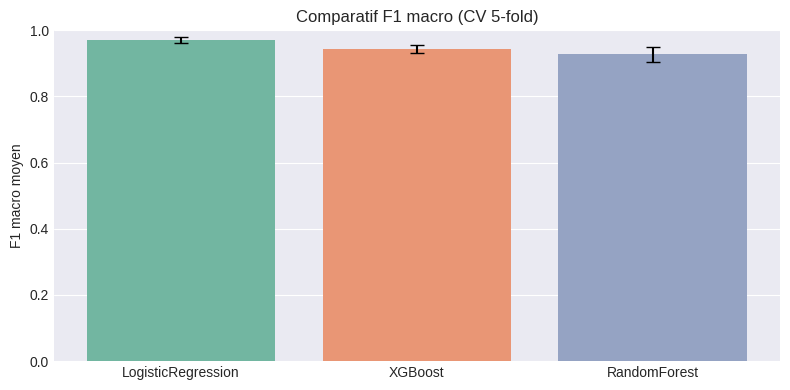

In [14]:
plt.figure(figsize=(8, 4))
sns.barplot(data=cv_results, x='Modele', y='F1_macro_mean', palette='Set2')
for i, row in cv_results.reset_index(drop=True).iterrows():
    plt.errorbar(i, row['F1_macro_mean'], yerr=row['F1_macro_std'], fmt='none', c='black', capsize=5)
plt.ylim(0.0, 1.0)
plt.title('Comparatif F1 macro (CV 5-fold)')
plt.xlabel('')
plt.ylabel('F1 macro moyen')
plt.tight_layout()
plt.show()


## Lecture métier (à commenter en soutenance)

- Si le modèle prédit encore trop souvent `faible`, vérifier la distribution de `hr_ratio_reserve`.
- Si XGBoost sur-apprend, réduire `max_depth` ou `n_estimators`.
- Pour la prod, figer le meilleur modèle + préprocessing + version du dataset.


In [ ]:
# Optionnel: sauvegarde des artefacts pour réutilisation dans l'app
# Décommente seulement si tu veux écrire les fichiers.

# import joblib
# artifacts_dir = BASE_DIR / 'artifacts_intensite_v4'
# artifacts_dir.mkdir(exist_ok=True)
#
# joblib.dump(rf, artifacts_dir / 'rf_v4.joblib')
# joblib.dump(xgb, artifacts_dir / 'xgb_v4.joblib')
# joblib.dump(lr, artifacts_dir / 'lr_v4.joblib')
# joblib.dump(le, artifacts_dir / 'label_encoder_xgb_v4.joblib')
#
# pd.Series(X_train_ohe.columns).to_csv(artifacts_dir / 'rf_xgb_columns_v4.csv', index=False)
# print('Artefacts sauvegardes dans', artifacts_dir)


In [ ]:
# Fonction d'inférence unitaire (alignée app.py)
def predict_one(age, weight, avg_bpm, resting_bpm, session_duration, workout_type):
    hr_max_theorique = 220 - age
    denom = hr_max_theorique - resting_bpm
    hr_ratio_reserve = (avg_bpm - resting_bpm) / denom if denom != 0 else np.nan
    bpm_reserve = avg_bpm - resting_bpm
    effort_load = hr_ratio_reserve * session_duration * (weight / 70.0) if np.isfinite(hr_ratio_reserve) else np.nan

    row = pd.DataFrame([{
        'Age': age,
        'Weight (kg)': weight,
        'Avg_BPM': avg_bpm,
        'Resting_BPM': resting_bpm,
        'Session_Duration (hours)': session_duration,
        'Workout_Type': workout_type,
        'hr_ratio_reserve': hr_ratio_reserve,
        'bpm_reserve': bpm_reserve,
        'effort_load': effort_load,
    }])

    row_ohe = pd.get_dummies(row, columns=['Workout_Type'], drop_first=True)
    row_ohe = row_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

    p_rf = rf.predict(row_ohe)[0]
    p_xgb = le.inverse_transform(xgb.predict(row_ohe))[0]
    p_lr = lr.predict(row)[0]

    return pd.DataFrame({
        'Modele': ['RandomForest', 'XGBoost', 'LogisticRegression'],
        'Prediction': [p_rf, p_xgb, p_lr],
    })


predict_one(age=60, weight=130, avg_bpm=155, resting_bpm=62, session_duration=1.0, workout_type='Cardio')


## Conclusion

Ce V4 est un compromis pratique:
- plus robuste méthodologiquement qu'un simple script d'app,
- plus réaliste métier qu'un V3 basé uniquement sur les quantiles de calories.

Prochaine étape conseillée: figer le meilleur modèle CV et l'intégrer dans `app.py` via chargement d'artefacts versionnés.
